In [1]:
from spin_sampler import Sampler , define_hopfield_model , initialize_spins
from binary_dimension import compute_histogram_jax, select_range, highest_prob_range , compute_histogram
from binary_dimension.utils import initial_gauss
from binary_dimension.optimization import DKL_Optimizer
from binary_dimension.distance_models import LinearDistanceModel , PolynomialDistanceModel
import numpy as np
import matplotlib.pyplot as plt 
import time

In [208]:
# Parameters of the simulationon
N = 1000
N_samples = 1000
dt_samples = 1
N_walkers = 1
T = 1.0
alpha = 0.04
mode = 'single_chain' 
backend = 'numba'  # 'numpy' or 'jax'
rnd_ord = True
seed = int(time.time()) #
seed = 1762354303
store = True

print(seed)
# Define the couplings of Hopfield model and initialize spins
p = int(alpha * N)
J , patterns = define_hopfield_model(N,p,N_walkers,mode,backend,seed)
initial_state = initialize_spins(N,N_walkers,mode,backend,seed)

# Create a sampler instance and sample
sampler = Sampler(J, T, mode,backend)
sampler.run_gibbs(initial_state,N_samples,dt_samples,rnd_ord,seed,store,progress=True);
S = sampler.get_chain()
sampler.reset_chain() # Clean up the sampler
print(f'Chain shape: {S.shape}') # (N_walkers,N_samples,N)
r , P = compute_histogram(S)


1762354303


100%|██████████| 1000/1000 [00:01<00:00, 865.81it/s]


Chain shape: (1000, 1000)


Initial parameters theta: [238.4786132    1.52113851]


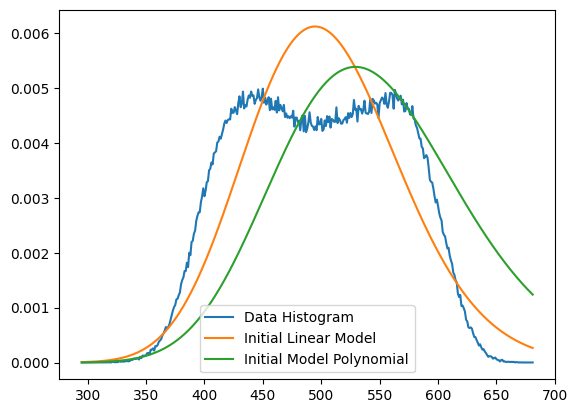

In [209]:
plt.plot(r,P,label='Data Histogram')
theta_init = initial_gauss(r,P)
print(f'Initial parameters theta: {theta_init}')

# Linear Model
distance_model = LinearDistanceModel()
dis_r = distance_model.d(r, theta_init)
# plt.plot(r,dis_r, label='Initial Linear Model Distance')
Pmod = distance_model.P_model(r, theta_init)
plt.plot(r,Pmod, label='Initial Linear Model')

# Polynomial Model
p = 2
distance_model = PolynomialDistanceModel(degree=p,N=N)
random_coeffs = np.random.rand(p-1) * 0.1
theta_init = [theta_init[0]/N, theta_init[1], *random_coeffs]
# theta_init = np.random.rand(p+1) * 0.000001
dis_r = distance_model.d(r, theta_init)
# plt.plot(r,dis_r,ls='--', label='Initial Polynomial Model Distance')
Pmod = distance_model.P_model(r, theta_init)
plt.plot(r,Pmod, label='Initial Model Polynomial')
# dr = distance_model.d(r, theta_init)
# plt.plot(r,dr, label='Initial Model Distance')
plt.legend()


In [228]:
Dkl_optimizer = DKL_Optimizer(r,P, distance_model)

theta_opt , log_DKL , Nit = Dkl_optimizer.optimize(theta_init,max_iter=1000,error=1e-10,lr=1.2)
print(f'Optimized parameters theta: {theta_opt}')
print(f'Log D_KL at optimum: {log_DKL}')
print(f'Number of iterations: {Nit}') 

Optimized parameters theta: [0.50647156 0.16031712 1.62179863]
Log D_KL at optimum: -1.6534854856005994
Number of iterations: 22


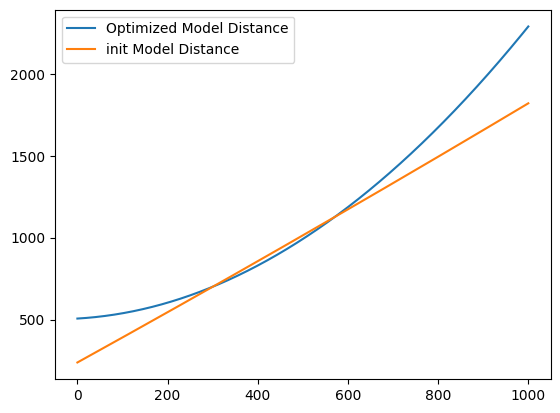

In [229]:
_r = np.arange(0,N+1)
dis_r = distance_model.d(_r, theta_opt)
plt.plot(_r,dis_r, label='Optimized Model Distance')
dis_r = distance_model.d(_r, theta_init)
plt.plot(_r,dis_r, label='init Model Distance')
# plt.plot(r,r)
plt.legend()

(200.0, 800.0)

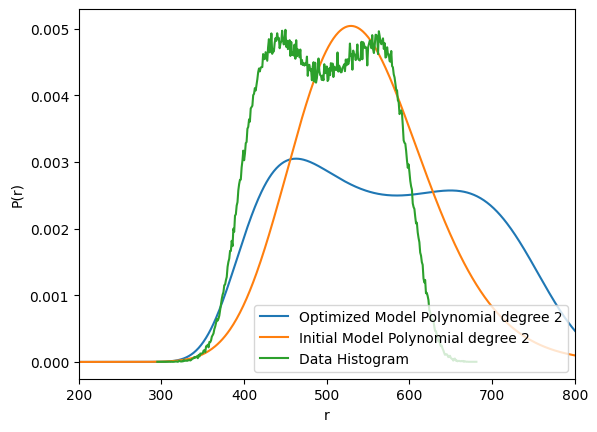

In [230]:
Pmod = distance_model.P_model(_r, theta_opt)
plt.plot(_r,Pmod, label=f'Optimized Model Polynomial degree {p}')
Pmod = distance_model.P_model(_r, theta_init)
plt.plot(_r,Pmod, label=f'Initial Model Polynomial degree {p}')
plt.plot(r,P,label='Data Histogram')
plt.legend()
plt.xlabel('r')
plt.ylabel('P(r)')
plt.xlim(200,800)